# Estudio de la movilidad en la Comunidad autónoma Vasca
## Contents
1. <a href='#section1'> Exploratory data analysis</a>
2. <a href='#section2'> Open Data Eus</a>
3. <a href="#section3"> Classification using scikit learn</a>


<a id="section1"></a>
## Exploratory data analysis

In [1]:
import os
import pandas as pd
import datetime
pd.set_option('display.max_info_rows', 10**7)


pr_fldr = 'D:/Ctym/p/p189_ModelosPaisVasco/'
input_fldr = pr_fldr + '1_Infobase/Ingartek/matrices/'
output_fldr = pr_fldr + '5_Trabajo/dev/outputs/'

# Check if the output folder exists
if not os.path.exists(output_fldr):
	os.mkdir(output_fldr)

In [12]:
display(df_gral_mob[df_gral_mob['MUNICIPIO_origin'].str.startswith('Barak')].head())

,origin,destination,date,age,gender,trips,MUNICIPIO_origin,PROVINCIA_origin,Comarca_x,MUNICIPIO_agrupado_origin,MUNICIPIO_destination,PROVINCIA_destination,Comarca_y,MUNICIPIO_agrupado_destination,Mes,Dia,Tipo_Dia,viaje_interno
10526,m48013,d0105902,2022-01-01,25-45,female,27.498928,Barakaldo,BIZKAIA,Gran Bilbao,Barakaldo,Vitoria-Gasteiz,ARABA / ÁLAVA,Llanada Alavesa,Vitoria-Gasteiz,enero,sábado,No Laborable,NO
10527,m48013,d0105902,2022-01-01,25-45,male,16.196794,Barakaldo,BIZKAIA,Gran Bilbao,Barakaldo,Vitoria-Gasteiz,ARABA / ÁLAVA,Llanada Alavesa,Vitoria-Gasteiz,enero,sábado,No Laborable,NO
10528,m48013,d0105903,2022-01-01,25-45,male,20.072063,Barakaldo,BIZKAIA,Gran Bilbao,Barakaldo,Vitoria-Gasteiz,ARABA / ÁLAVA,Llanada Alavesa,Vitoria-Gasteiz,enero,sábado,No Laborable,NO
10529,m48013,d0105905,2022-01-01,25-45,female,19.994870,Barakaldo,BIZKAIA,Gran Bilbao,Barakaldo,Vitoria-Gasteiz,ARABA / ÁLAVA,Llanada Alavesa,Vitoria-Gasteiz,enero,sábado,No Laborable,NO
10530,m48013,d4802001,2022-01-01,0-25,female,973.906690,Barakaldo,BIZKAIA,Gran Bilbao,Barakaldo,Bilbao,BIZKAIA,Gran Bilbao,Bilbao,enero,sábado,No Laborable,NO


In [7]:
display(df_gral_mob[df_gral_mob['origin'].str.startswith('d')]['origin'].unique())

array(['d0105901', 'd0105902', 'd0105903', 'd0105904', 'd0105905',
       'd0105906', 'd2006901', 'd2006902', 'd2006903', 'd2006904',
       'd2006905', 'd2006906', 'd2006907', 'd4802001', 'd4802002',
       'd4802003', 'd4802004', 'd4802005', 'd4802006', 'd4802007',
       'd4802008'], dtype=object)

In [2]:
# Este fichero corresponde a las matrices de movilidad general obtenidas mediante telefonía móvil. Contiene información sobre edad y género
df_gral_mob = pd.read_csv(os.path.join(input_fldr,'Viajes Intermunicipales Edad y Genero (Matriz OD).csv'), sep = ';', encoding='utf-8')
df_gral_mob['date'] = pd.to_datetime(df_gral_mob['date'], format = "%Y-%m-%d")
# df_gral_mob.head(10)
# df_gral_mob.info()
# df_gral_mob.describe()

df_gral_mob['trips'] = df_gral_mob['trips'].str.replace(',', '.').astype(float)

for col in df_gral_mob.columns[3:]:
	print(f"Values in column {col}:")
	display(df_gral_mob[col].unique())

Values in column age:


array(['0-25', '25-45', '45-65', '65-100', nan], dtype=object)

Values in column gender:


array(['female', 'male', nan], dtype=object)

Values in column trips:


...

array(['sábado', 'domingo', 'lunes', 'martes', 'miércoles', 'jueves',
       'viernes'], dtype=object)

Values in column Tipo_Dia:


array(['No Laborable', 'Laborable'], dtype=object)

Values in column viaje_interno:


array(['SI', 'NO'], dtype=object)

In [5]:
# Este fichero corresponde a la matriz de desplazamientos en transporte público.
df_PT = pd.read_csv(os.path.join(input_fldr,'Viajes Intermunicipales F.csv'), sep = ';', encoding='utf-8')
df_PT['date'] = pd.to_datetime(df_PT['date'], format = "%Y-%m-%d")
df_PT.head(10)
df_PT.info()
df_PT.describe()

for col in df_PT.columns[3:]:
	print(f"Values in column {col}:")
	display(df_PT[col].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8388488 entries, 0 to 8388487
Data columns (total 16 columns):
 #   Column                          Non-Null Count    Dtype         
---  ------                          --------------    -----         
 0   origin                          8388488 non-null  object        
 1   destination                     8388488 non-null  object        
 2   date                            8388488 non-null  datetime64[ns]
 3   trips                           8388488 non-null  object        
 4   MUNICIPIO_origin                8388488 non-null  object        
 5   PROVINCIA_origin                8388488 non-null  object        
 6   Comarca_x                       8388488 non-null  object        
 7   MUNICIPIO_agrupado_origin       8388488 non-null  object        
 8   MUNICIPIO_destination           8388488 non-null  object        
 9   PROVINCIA_destination           8388488 non-null  object        
 10  Comarca_y                       8388488 no

array(['15969,889932248256', '19506,6918434205', '16612,281271284206',
       ..., '33,54366480596', '1,14031900517', '34,07602185582'],
      dtype=object)

Values in column MUNICIPIO_origin:


array(['Vitoria-Gasteiz', 'Donostia / San Sebastián', 'Bilbao',
       'Alegría-Dulantzi', 'Amurrio', 'Aramaio', 'Artziniega', 'Armiñón',
       'Arratzua-Ubarrundia', 'Asparrena', 'Ayala / Aiara',
       'Baños de Ebro / Mañueta', 'Barrundia', 'Berantevilla', 'Bernedo',
       'Campezo / Kanpezu', 'Zigoitia', 'Kripan', 'Kuartango',
       'Elburgo / Burgelu', 'Elciego', 'Elvillar / Bilar',
       'Iruraiz-Gauna', 'Labastida / Bastida', 'Lagrán', 'Laguardia',
       'Lanciego / Lantziego', 'Lapuebla de Labarca', 'Leza',
       'Laudio / Llodio', 'Arraia-Maeztu',
       'Moreda de Álava / Moreda Araba', 'Navaridas', 'Okondo',
       'Oyón-Oion', 'Peñacerrada-Urizaharra',
       'Erriberagoitia / Ribera Alta', 'Ribera Baja / Erribera Beitia',
       'Añana', 'Agurain / Salvatierra', 'Samaniego',
       'San Millán / Donemiliaga', 'Urkabustaiz', 'Valdegovía / Gaubea',
       'Harana / Valle de Arana', 'Villabuena de Álava / Eskuernaga',
       'Legutio', 'Yécora / Iekora', 'Zalduondo', 'Z

Values in column PROVINCIA_origin:


...

array(['sábado', 'domingo', 'lunes', 'martes', 'miércoles', 'jueves',
       'viernes'], dtype=object)

Values in column Tipo_Dia:


array(['No Laborable', 'Laborable'], dtype=object)

Values in column viaje_interno:


array(['SI', 'NO'], dtype=object)

<a id="section2"></a>
## Open data Eus

In [6]:
import requests
import json
import pandas as pd

def fetch_data(response):
	if response.status_code == 200:
		return response.json()
	else:
		print(f"Error {response.status_code}: {response.text}")
		return None

def flatten_data(data):
	flattened_data = [
			{
					"municipality": municipality["name"],
					"year": year,
					"metric": value
			}
			for municipality in data["municipalities"]
			for year_data in municipality["years"]
			for year, value in year_data.items()
	]
	return pd.DataFrame(flattened_data)


In [ ]:
import os
import pandas as pd
import requests

def fetch_data(response):
	if response.status_code == 200:
		return response.json()
	else:
		print(f"Error {response.status_code}: {response.text}")
		return None

def flatten_data(data):
	flattened_data = [
			{
					"municipality": municipality["name"],
					"year": year,
					"metric": value
			}
			for municipality in data["municipalities"]
			for year_data in municipality["years"]
			for year, value in year_data.items()
	]
	return pd.DataFrame(flattened_data)


all_indicators_url = 'https://api.euskadi.eus/udalmap/indicators?lang=SPANISH&summarized=false'
all_indicators_data = fetch_data(requests.get(all_indicators_url))  # List with all available information

socioec_dict = {}
for indicator in all_indicators_data:
    id = indicator['id']
    response2 = requests.get(f'https://api.euskadi.eus/udalmap/indicators/{id}/municipalities?lang=SPANISH')
    data = fetch_data(response2)
    if data:
        socioec_dict[id] = flatten_data(data)

In [7]:
import os
import pandas as pd
import requests

# Step 1: Extract the list of indicators available in Udalmap
all_indicators_url = 'https://api.euskadi.eus/udalmap/indicators?lang=SPANISH&summarized=false'
all_indicators_data = fetch_data(requests.get(all_indicators_url))  # List with all available information

# Step 2: Extract and process all indicators
socioec_dict = {}
for indicator in all_indicators_data:
    id = indicator['id']
    response2 = requests.get(f'https://api.euskadi.eus/udalmap/indicators/{id}/municipalities?lang=SPANISH')
    data = fetch_data(response2)
    if data:
        socioec_dict[id] = flatten_data(data)

# Step 3: Filter the socio-economic dictionary by year
base_yr = '2022'

# Filter indicators whose latest year >= base year
f_socioec_dict = {id: df for id, df in socioec_dict.items() if df['year'].max() >= base_yr}
max_yr = {id: df['year'].max() for id, df in f_socioec_dict.items()}

# Validate that all data includes the base year
min_yr = min(max_yr.values())
assert min_yr == base_yr, (
    f"The minimum year in the data ({min_yr}) is not equal to the specified base year ({base_yr})"
)

print(f"The original database contained {len(socioec_dict)} indicators.")
print(f"Filtered database contains {len(f_socioec_dict)} indicators. All of them are available at least until {base_yr}.")

# Step 4: Create a dictionary for indicator names and metadata
id_name_dict = {}
for id, df in f_socioec_dict.items():
    indicator_info = next((indicator for indicator in all_indicators_data if indicator['id'] == id), None)
    if indicator_info:
        id_name_dict[id] = {
            'name': indicator_info['name'],
            'href': indicator_info['_links']['self']['href'],
            'is_percent': '%' in indicator_info['name']
        }

# Convert to DataFrame
id_name_df = pd.DataFrame.from_dict(id_name_dict, orient='index')

# Add additional metadata to the DataFrame
id_name_df['Latest_yr'] = id_name_df.index.map(max_yr)
no_municipalities = {id: len(df['municipality'].unique()) for id, df in f_socioec_dict.items()}
id_name_df['No_municipalities'] = id_name_df.index.map(no_municipalities)

# Step 5: Clean the name column
if 'name' in id_name_df.columns:
    id_name_df['name'] = id_name_df['name'].str.replace('&#x2030;', 'tasa por 1000', regex=False)
    id_name_df['name'] = id_name_df['name'].str.replace('&#x20AC;', '€', regex=False)

# Display the resulting DataFrame
print(id_name_df)

# Step 6: Optionally, save the DataFrame to a CSV file
os.makedirs(output_fldr, exist_ok=True)
id_name_df.to_csv(os.path.join(output_fldr, 'latest_indicators_f.csv'), index=True, encoding='utf-8')

The original database contained 222 indicators.
Filtered database contains 161 indicators. All of them are available at least until 2022.
                                                  name  \
7    Población de 16 y más años ocupada en el secto...   
8                                Tasa de actividad (%)   
17   Empleo generado por las microempresas (0-9 emp...   
44   Índice de sobreenvejecimiento: Población de 75...   
46             Tasa bruta de natalidad (tasa por 1000)   
..                                                 ...   
64   Renta personal derivada del trabajo (% renta p...   
82    Oficinas de Correos (por cada 10.000 habitantes)   
28   Plazas de alojamiento turístico (tasa por 1000...   
113              Superficie destinada a carreteras (%)   
132     Teléfonos públicos (por cada 1.500 habitantes)   

                                               href  is_percent Latest_yr  \
7      https://api.euskadi.eus/udalmap/indicators/7        True      2023   
8      http

### Save metrics as csv files

In [8]:
for id, df in f_socioec_dict.items():
    filename = f"{id}.csv"  # id used as filename 
    file_path = os.path.join(output_fldr, filename)
    df.to_csv(file_path, encoding='utf-8', index = False)

In [9]:
# Replace '/ ' with '/' (no blanks) 
columns_to_replace = ['MUNICIPIO_origin', 'MUNICIPIO_destination', 'MUNICIPIO_agrupado_origin', 'MUNICIPIO_agrupado_destination']
df_gral_mob[columns_to_replace] = df_gral_mob[columns_to_replace].apply(lambda col: col.str.replace(' / ', '/', regex=False))

# Replace name mismatches
mismathc_dict = {
	'Agurain/Salvatierra': 'Salvatierra/Agurain',
	'Donostia/San Sebastián': 'Donostia / San Sebastián',
	'Irún': 'Irun',
	'Trucíos-Turtzioz': 'Trucios-Turtzioz',
	'Moreda de Álava/Moreda Araba': 'Moreda de Álava / Moreda Araba'
}

df_gral_mob[columns_to_replace] = df_gral_mob[columns_to_replace].replace(mismathc_dict)

### By origin

In [27]:
criteria = ['MUNICIPIO_origin']

# Trips per 1000 inhabitants
by_origin = df_gral_mob.groupby(criteria).agg(
    trips = ('trips', 'sum'),
    rows = ('trips', 'count'),
    std_trips = ('trips', 'std')
).reset_index()

display(by_origin.head())
by_origin.info()
# Important features: Total population per municipality is id: 162

# Generate the matrix containing the population info
population = f_socioec_dict['162']
population_2023 = population.loc[population['year'] == base_yr]

# # display(population.head())
# # display(population_2023.head())
# population_2023.info()

# Match Municipio origen
mob_filtered = by_origin[~by_origin['MUNICIPIO_origin'].isin(population['municipality'])]
print(f'Original matrix length: {len(by_origin)}')
print(f'Non-matched matrix length: {len(mob_filtered)}')
print(f'\nPercentage of rows unmatched: {round(len(mob_filtered)/len(by_origin)*100,2)}%')
Non_matched = mob_filtered['MUNICIPIO_origin'].unique()

if len(Non_matched) > 0:
    Non_matched_df = pd.DataFrame(Non_matched, columns=['Origen'])
    display(Non_matched)
    Non_matched_df.to_csv(os.path.join(output_fldr,'unmatched_locations.csv'), encoding='utf-8')
else:
    print('\nHappy days! All locations matched')

del mob_filtered

# Merge population
by_origin = by_origin.merge(population_2023[['municipality','metric']], 
                                  left_on='MUNICIPIO_origin', 
                                  right_on='municipality', 
                                  how='left')

# Rename the 'index' column to a meaningful name if needed
by_origin.rename(columns={'index': 'municipality_id','metric': f'population_{base_yr}'}, inplace=True)

# Calculate the trip rates
by_origin['trips_per_inhab'] = by_origin['trips'] / by_origin[f'population_{base_yr}']

display(by_origin.head())

by_origin.to_csv(os.path.join(output_fldr,'vectores_origen.csv'), encoding='utf-8', index= False)

,MUNICIPIO_origin,trips,rows,std_trips
0,Abadiño,6.521260e+06,56060,236.955119
1,Abaltzisketa,3.516070e+04,1619,6.555251
2,Abanto y Ciérvana-Abanto Zierbena,1.024907e+07,61764,243.502004
3,Aduna,6.346195e+05,16757,23.638222
4,Aia,3.664501e+06,33420,200.834486


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MUNICIPIO_origin  251 non-null    object 
 1   trips             251 non-null    float64
 2   rows              251 non-null    int64  
 3   std_trips         251 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 8.0+ KB
Original matrix length: 251
Non-matched matrix length: 0

Percentage of rows unmatched: 0.0%

Happy days! All locations matched


,MUNICIPIO_origin,trips,rows,std_trips,municipality,population_2022,trips_per_inhab
0,Abadiño,6.521260e+06,56060,236.955119,Abadiño,7722.0,844.503965
1,Abaltzisketa,3.516070e+04,1619,6.555251,Abaltzisketa,304.0,115.660198
2,Abanto y Ciérvana-Abanto Zierbena,1.024907e+07,61764,243.502004,Abanto y Ciérvana-Abanto Zierbena,9331.0,1098.389721
3,Aduna,6.346195e+05,16757,23.638222,Aduna,483.0,1313.912084
4,Aia,3.664501e+06,33420,200.834486,Aia,2072.0,1768.581579


### By destination

In [32]:
criteria = ['MUNICIPIO_destination']

# Trips per 1000 inhabitants
by_destination = df_gral_mob.groupby(criteria).agg(
    trips = ('trips', 'sum'),
    rows = ('trips', 'count'),
    std_trips = ('trips', 'std')
).reset_index()

display(by_destination.head())
by_destination.info()
# Important features: Total population per municipality is id: 162

# Generate the matrix containing the population info
population = f_socioec_dict['162']
population_2023 = population.loc[population['year'] == base_yr]

# # display(population.head())
# # display(population_2023.head())
# population_2023.info()

# Match Municipio origen
mob_filtered = by_destination[~by_destination['MUNICIPIO_destination'].isin(population['municipality'])]
print(f'Original matrix length: {len(by_destination)}')
print(f'Non-matched matrix length: {len(mob_filtered)}')
print(f'\nPercentage of rows unmatched: {round(len(mob_filtered)/len(by_destination)*100,2)}%')
Non_matched = mob_filtered['MUNICIPIO_destination'].unique()

if len(Non_matched) > 0:
    Non_matched_df = pd.DataFrame(Non_matched, columns=['Origen'])
    display(Non_matched)
    Non_matched_df.to_csv(os.path.join(output_fldr,'unmatched_locations.csv'), encoding='utf-8')
else:
    print('\nHappy days! All locations matched')

del mob_filtered

# Merge population
by_destination = by_destination.merge(population_2023[['municipality','metric']], 
                                  left_on='MUNICIPIO_destination', 
                                  right_on='municipality', 
                                  how='left')

# Rename the 'index' column to a meaningful name if needed
by_destination.rename(columns={'index': 'municipality_id', 'metric': f'population_{base_yr}'}, inplace=True)

# Calculate the trip rates
by_destination['trips_per_inhab'] = by_destination['trips'] / by_destination[f'population_{base_yr}']

display(by_destination.head())

by_destination.to_csv(os.path.join(output_fldr,'vectores_destino.csv'), encoding='utf-8', index= False)

,MUNICIPIO_destination,trips,rows,std_trips
0,Abadiño,6.585826e+06,55667,245.726881
1,Abaltzisketa,3.643251e+04,1687,6.494277
2,Abanto y Ciérvana-Abanto Zierbena,1.020718e+07,61590,241.979255
3,Aduna,6.306308e+05,16509,25.231480
4,Aia,3.623420e+06,34047,191.720652


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   MUNICIPIO_destination  251 non-null    object 
 1   trips                  251 non-null    float64
 2   rows                   251 non-null    int64  
 3   std_trips              251 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 8.0+ KB
Original matrix length: 251
Non-matched matrix length: 0

Percentage of rows unmatched: 0.0%

Happy days! All locations matched


,MUNICIPIO_destination,trips,rows,std_trips,municipality,population_2022,trips_per_inhab
0,Abadiño,6.585826e+06,55667,245.726881,Abadiño,7722.0,852.865265
1,Abaltzisketa,3.643251e+04,1687,6.494277,Abaltzisketa,304.0,119.843780
2,Abanto y Ciérvana-Abanto Zierbena,1.020718e+07,61590,241.979255,Abanto y Ciérvana-Abanto Zierbena,9331.0,1093.899760
3,Aduna,6.306308e+05,16509,25.231480,Aduna,483.0,1305.653732
4,Aia,3.623420e+06,34047,191.720652,Aia,2072.0,1748.754834


<a id="section3"></a>
## Classification using scikit learn

In [15]:
# Ensure consistent data types
import numpy as np
from sklearn.preprocessing import StandardScaler


# Trips per 1000 inhabitants. Excluding internal trips
by_origin = df_gral_mob.groupby('MUNICIPIO_origin').agg(
    trips = ('trips', 'sum')
).reset_index()

# Generate the matrix containing the population info
population = f_socioec_dict['162']
population_2023 = population.loc[population['year'] == base_yr]

# Merge population
population_base_yr = population.loc[population['year'] == base_yr]
by_origin = by_origin.merge(population_base_yr[['municipality', 'metric']], 
                                  left_on='MUNICIPIO_origin', 
                                  right_on='municipality', 
                                  how='left')

# Rename the 'index' column to a meaningful name if needed
by_origin.rename(columns={'index': 'municipality_id', 'metric': f'population_{base_yr}'}, inplace=True)
# Calculate the trip rates
by_origin['trips_per_inhab'] = by_origin['trips'] / by_origin[f'population_{base_yr}']


y = by_origin['trips_per_inhab'].astype(float)
x = pd.DataFrame()

regressors = {}

# Loop through socio-economic regressors and merge them with `by_origin`
for key, regressor in f_socioec_dict.items():
    regressor_base_yr = regressor.loc[regressor['year'] == base_yr]
    regressor_merged = by_origin.merge(
        regressor_base_yr[['municipality', 'metric']],  # Select relevant columns
        left_on='MUNICIPIO_origin',                       # Key in `by_origin`
        right_on='municipality',                          # Key in `regressor_base_yr`
        how='left'                                        # Ensure all rows from `by_origin` are kept
    )
    regressors[key] = regressor_merged['metric']

# Combine all regressors into a single DataFrame
x = pd.concat(regressors, axis=1)
x.columns = regressors.keys()  # Set the column names to regressor keys

# Handle missing values
x = x.fillna(0)

# Normalize features using StandardScaler
scaler = StandardScaler()
x_normalized = scaler.fit_transform(x)

# Combine `x` and `y` into a single matrix
result = np.hstack([x_normalized, y.values.reshape(-1, 1)])  # Append `y` as the last column

# Check the resulting matrix dimensions
print(f"Regressor matrix shape: {x_normalized.shape}")
print(f"Final matrix shape: {result.shape}")

Regressor matrix shape: (251, 161)
Final matrix shape: (251, 162)


In [16]:
# Convert the NumPy matrix back to a DataFrame for saving
result_df = pd.DataFrame(
    result,
    columns=list(x.columns) + ['trips_per_inhab']  # Add column names
)

display(result_df)
result_df['trips_per_inhab'].describe()
result_df.to_csv(os.path.join(output_fldr,'matrix.csv'), encoding = 'utf-8', index= True)

,7,8,17,44,46,86,102,158,159,160,...,182,184,191,59,64,82,28,113,132,trips_per_inhab
0,-0.457525,-0.084054,-1.099021,-0.416791,0.101420,0.242837,-0.654851,-0.538627,0.098412,0.227041,...,-0.017945,-0.559727,0.461095,-0.083474,0.632373,-0.093657,-0.266056,0.375644,-0.680856,844.503965
1,-1.492976,1.795800,0.318921,-0.916089,1.094094,-1.058133,0.862680,1.014154,-0.216782,-0.566871,...,2.094478,-1.364393,0.150980,-0.533886,0.144181,-0.532678,-0.351594,-0.603999,-0.680856,115.660198
2,0.976175,0.683365,-0.840258,-0.643745,-0.286741,0.322075,-0.322891,-0.228071,-0.119799,-0.070331,...,-0.036286,-0.967205,0.786716,0.424754,0.812482,-0.171330,-0.348855,1.178629,0.299186,1098.389721
3,0.108767,0.799445,-1.253066,-1.362432,-0.016301,1.768621,3.565782,1.531747,0.508582,2.828002,...,1.713638,0.456616,1.110927,-1.074754,1.256437,-0.532678,0.344805,-0.571879,-0.680856,1313.912084
4,-0.271028,0.660794,-0.087014,-1.029566,0.324135,-0.018370,-0.038354,-0.642146,-0.123406,-0.024929,...,-3.134795,0.030617,0.408940,-0.290496,0.535998,1.098453,2.123253,-0.662884,-0.680856,1768.581579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,-1.345332,-0.206583,2.168271,0.298114,-0.426734,-1.345139,-0.654851,-0.952702,-0.213946,-0.408964,...,-0.969507,1.128690,-0.565103,0.753938,-0.290294,-0.532678,0.481168,-0.389869,-0.680856,553.699975
247,-0.182635,-0.100176,-0.690660,-0.163359,0.670935,0.340502,-0.560005,-0.228071,0.072216,-0.540734,...,0.780417,-0.216340,-0.314192,-0.352976,0.014628,-0.532678,-0.314207,-0.523700,0.911713,733.323300
248,1.102450,1.125115,-0.125424,-0.276836,0.050513,-0.555528,0.009069,0.393041,-0.188773,0.122423,...,0.394182,1.271572,0.943183,0.330569,0.570756,0.892451,0.130357,-0.389869,-0.680856,596.807983
249,-0.099100,0.206146,-0.585942,-0.579441,-0.337648,1.166047,-1.176502,-1.056221,-0.102903,-0.237989,...,0.273349,0.274927,0.269388,-0.327797,0.098364,-0.194969,0.091824,0.257872,1.156724,742.928245


d:\Documents\Proyectos\Scripts\myenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.490e+03, tolerance: 7.885e+03
  model = cd_fast.enet_coordinate_descent(
d:\Documents\Proyectos\Scripts\myenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.666e+03, tolerance: 7.885e+03
  model = cd_fast.enet_coordinate_descent(
d:\Documents\Proyectos\Scripts\myenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisati

Feature importance from Lasso Regression:
7        0.000000
8        0.000000
17      -0.000000
44      -0.000000
46      12.102790
          ...    
64      -0.000000
82     -11.486560
28     147.231081
113      0.000000
132      0.000000
Length: 161, dtype: float64


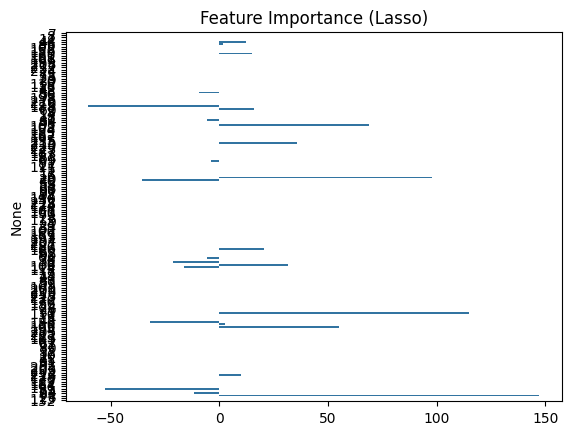

Random Forest Mean Squared Error: 182052.60
Random Forest R^2 Score: 0.14


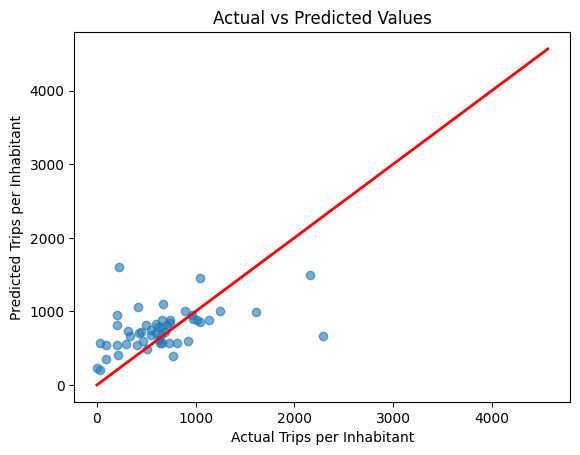

Model saved to D:/Ctym/p/p189_ModelosPaisVasco/5_Trabajo/dev/outputs/trip_prediction_model.pkl


In [18]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


# pca = PCA(n_components=0.95)  # Keep 95% variance
# X = pca.fit_transform(x_normalized)
# print(f"PCA reduced features to {X.shape[1]} dimensions.")

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(x_normalized, y, test_size=0.2, random_state=42)

# Step 4: Feature Importance Analysis with Lasso
lasso = LassoCV(cv=5).fit(X_train, y_train)
feature_importance = pd.Series(lasso.coef_, index=x.columns)
print("Feature importance from Lasso Regression:")
print(feature_importance)

# Plot feature importance
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title("Feature Importance (Lasso)")
plt.show()

# Step 5: Model Training with Random Forest
rf = RandomForestRegressor(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)

# Evaluate Model
y_pred = rf.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Random Forest Mean Squared Error: {mse:.2f}")
print(f"Random Forest R^2 Score: {r2:.2f}")

# Step 6: Visualize Results
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.xlabel("Actual Trips per Inhabitant")
plt.ylabel("Predicted Trips per Inhabitant")
plt.title("Actual vs Predicted Values")
plt.show()

# Save Model (Optional)
import joblib
model_file = os.path.join(output_fldr, 'trip_prediction_model.pkl')
joblib.dump(rf, model_file)
print(f"Model saved to {model_file}")

In [24]:
display(f_socioec_dict['1']['municipality'].values)

array(['Lagrán', 'Lagrán', 'Lagrán', ..., 'Gorliz', 'Gorliz', 'Gorliz'],
      dtype=object)

## Repository of old functions

In [ ]:
def export_overall_trip_rates(df_gral_mob, f_socioec_dict, output_fldr):
	population = f_socioec_dict['162']
	base_yr = '2022'
	population_base_yr = population[population['year'] == base_yr]
	display(population_base_yr.head())
	
	criteria_O = 'MUNICIPIO_origin'
	criteria_D = 'MUNICIPIO_destination'
	
	by_origin = df_gral_mob.groupby(criteria_O).agg(
		trips = ('trips', 'sum'),
		rows = ('trips', 'count'),
		std_trips = ('trips', 'std')
	).reset_index()

	population_base_yr.set_index('municipality', inplace=True)
	by_origin = by_origin.merge(population_base_yr[['id','metric']], left_on='MUNICIPIO_origin', right_index=True, how='left')
	by_origin['trips_per_inhab'] = by_origin['trips'] / by_origin['metric']
	by_origin.rename(columns={'metric': f'population_{base_yr}', 'id': 'id_municipio'}, inplace = True)

	by_dest = df_gral_mob.groupby(criteria_D).agg(
		trips = ('trips', 'sum'),
		rows = ('trips', 'count'),
		std_trips = ('trips', 'std')
	).reset_index()

	by_dest = by_dest.merge(population_base_yr[['metric']], left_on='MUNICIPIO_destination', right_index=True, how='left')
	by_dest['trips_per_inhab'] = by_dest['trips'] / by_dest['metric']
	by_dest.rename(columns={'metric': f'population_{base_yr}'}, inplace = True)

	by_origin.to_csv(os.path.join(output_fldr,'vectores_origen.csv'), encoding='utf-8', index= False)
	by_dest.to_csv(os.path.join(output_fldr,'vectores_destino.csv'), encoding='utf-8', index= False)
	return(by_origin, by_dest)